
# 📊 BANK MARKETING DATA MINING PROJECT

## Pipeline:
EDA → Preprocessing → Clustering → Classification → Semi-supervised → Evaluation


## 1. EDA

In [1]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/bank+marketing/bank/bank.csv", sep=';')

df.head()


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [2]:

df.info()
df.describe()
df.isnull().sum()


<class 'pandas.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        4521 non-null   int64
 1   job        4521 non-null   str  
 2   marital    4521 non-null   str  
 3   education  4521 non-null   str  
 4   default    4521 non-null   str  
 5   balance    4521 non-null   int64
 6   housing    4521 non-null   str  
 7   loan       4521 non-null   str  
 8   contact    4521 non-null   str  
 9   day        4521 non-null   int64
 10  month      4521 non-null   str  
 11  duration   4521 non-null   int64
 12  campaign   4521 non-null   int64
 13  pdays      4521 non-null   int64
 14  previous   4521 non-null   int64
 15  poutcome   4521 non-null   str  
 16  y          4521 non-null   str  
dtypes: int64(7), str(10)
memory usage: 600.6 KB


age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

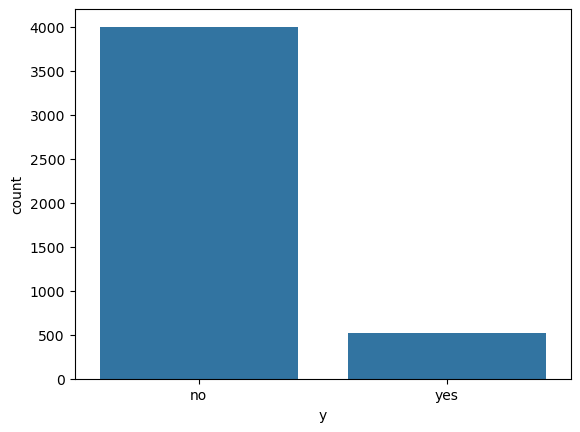

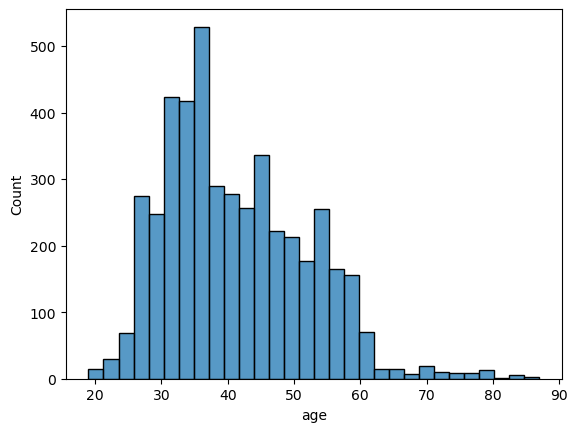

In [3]:

sns.countplot(x='y', data=df)
plt.show()

sns.histplot(df['age'], bins=30)
plt.show()


## 2. Preprocessing

In [4]:

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

df.to_csv("../data/processed/bank_clean.csv", index=False)
df.head()


C:\Users\Duong\AppData\Local\Temp\ipykernel_15872\3976072971.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,10,1,0,0,1787,0,0,0,19,10,79,1,-1,0,3,0
1,33,7,1,1,0,4789,1,1,0,11,8,220,1,339,4,0,0
2,35,4,2,2,0,1350,1,0,0,16,0,185,1,330,1,0,0
3,30,4,1,2,0,1476,1,1,2,3,6,199,4,-1,0,3,0
4,59,1,1,1,0,0,1,0,2,5,8,226,1,-1,0,3,0


## 3. Clustering

In [5]:

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(df)

df.groupby('cluster').mean()


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
cluster,,,,,,,,,,,,,,,,,
0,42.911111,4.630769,1.148718,1.307692,0.000000,5202.864957,0.505983,0.102564,0.630769,16.232479,5.748718,275.347009,2.745299,35.276923,0.588034,2.553846,0.157265
1,40.845577,4.385929,1.145370,1.214692,0.019659,543.930678,0.576824,0.161666,0.654423,15.876617,5.503880,263.379721,2.796948,40.297465,0.531816,2.562597,0.109933
2,44.542857,3.971429,1.271429,1.514286,0.000000,18361.771429,0.471429,0.085714,0.714286,15.400000,5.800000,200.928571,3.014286,47.971429,0.757143,2.414286,0.057143


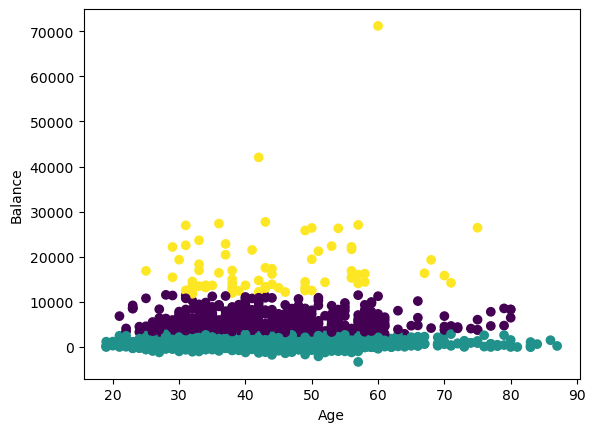

In [6]:

plt.scatter(df['age'], df['balance'], c=df['cluster'])
plt.xlabel("Age")
plt.ylabel("Balance")
plt.show()


## 4. Classification

In [7]:

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X = df.drop('y', axis=1)
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.92      0.98      0.95       807
           1       0.62      0.31      0.41        98

    accuracy                           0.90       905
   macro avg       0.77      0.64      0.68       905
weighted avg       0.89      0.90      0.89       905



## 5. Semi-supervised

In [8]:

import numpy as np

mask = np.random.rand(len(y)) < 0.2

y_semi = y.copy()
y_semi[~mask] = -1

print("Labeled:", sum(mask))
print("Unlabeled:", sum(~mask))


Labeled: 916
Unlabeled: 3605


## 6. Evaluation

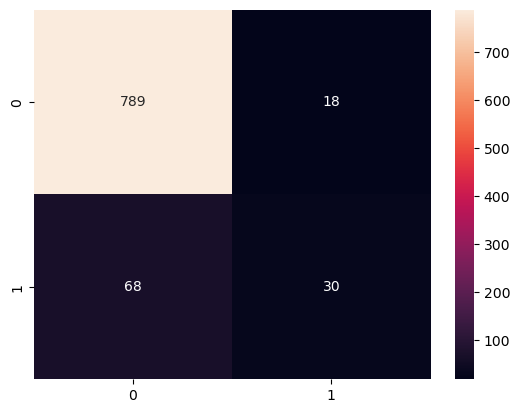

In [9]:

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.show()
